In [2]:
pip install geopandas shapely pyproj fiona matplotlib pandas

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 5.8 MB/s  0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ------ --------------------------------- 1.0/6.3 MB 5.0 MB/s eta 0:00:02
   ---------------- ----------------------- 2.6/6.3 MB 6.3 MB/s eta 0:00:01
   -------------------------- ------------- 4.2/6.3 MB 6.8 MB/s eta 0:00:01
   --------------------------------- ------ 5.2/6.3 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 6.1 MB/s  0:00:01
   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   -- ------------------------------------- 1.3/24.5 MB 7.4 MB/s eta 0:00:04
   ---- ----------------------------------- 2.6/24.5 MB 7.2 MB/s eta 0:00:04
   ------- -------------------------------- 4.5/24.5 MB 7.3 MB/s eta 0:00:03
   --------- ----------------------

In [5]:
# If needed, install geopandas before running this notebook:
# %pip install geopandas shapely pyproj fiona matplotlib pandas

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("C:\CMPINF")
if not (DATA_DIR / "neighborhoods.geojson").exists() and Path("/mnt/data/neighborhoods.geojson").exists():
    DATA_DIR = Path("/mnt/data")

NEIGHBORHOODS_FILE = DATA_DIR / "neighborhoods.geojson"
STOPS_FILE = DATA_DIR / "stops.geojson"
SIZE_FILE = DATA_DIR / "neighborhood_size.csv"
TREES_FILE = DATA_DIR / "Pittsburgh_Trees.csv"

for path in [NEIGHBORHOODS_FILE, STOPS_FILE, SIZE_FILE]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

print("Required data files found.")

Required data files found.


## 1. Load the datasets

- `neighborhoods.geojson`: Pittsburgh neighborhood boundaries.
- `stops.geojson`: Pittsburgh Regional Transit stop locations.
- `neighborhood_size.csv`: neighborhood area/size table used to normalize the metric.
- `Pittsburgh_Trees.csv`: optional, used only to demonstrate alignment with another project part.


In [6]:
neighborhoods = gpd.read_file(NEIGHBORHOODS_FILE)
stops = gpd.read_file(STOPS_FILE)
size = pd.read_csv(SIZE_FILE)

print("Neighborhood boundaries:", neighborhoods.shape)
print("Transit stops:", stops.shape)
print("Neighborhood size:", size.shape)

display(neighborhoods.head(3))
display(stops.head(3))
display(size.head())

Neighborhood boundaries: (90, 40)
Transit stops: (6426, 36)
Neighborhood size: (90, 2)


,OBJECTID,fid_blockg,statefp10,countyfp10,tractce10,blkgrpce10,geoid10,namelsad10,mtfcc10,funcstat10,aland10,awater10,intptlat10,intptlon10,shape_leng,fid_neighb,perimeter,neighbor_,neighbor_i,hood,hood_no,acres,sqmiles,dpwdiv,unique_id,sectors,shape_le_1,shape_ar_1,page_number,plannerassign,created_user,created_date,last_edited_user,last_edited_date,temp,pghdb_sde_Neighborhood_2010_are,GlobalID,Shape__Area,Shape__Length,geometry
0,1,233,42,003,140500,3,420031405003,Block Group 3,G5030,S,172851,0,+40.4523867,-079.9073195,6787.527650,71,136797.979285,48,2130,Point Breeze North,64,193.229239,0.301921,2,113,11,13891.873348,7.968760e+06,15,Adriana Bowman,SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 13:02:13+00:00,None,7968760.0,a642a6b6-a2a9-48d5-acf2-3e2ce87d4bc0,8.417067e+06,14181.728584,"POLYGON ((-79.90531 40.45549, -79.90488 40.455..."
1,2,203,42,003,140100,3,420031401003,Block Group 3,G5030,S,291302,0,+40.4427301,-079.9435821,8071.734942,66,136797.979285,55,2137,Squirrel Hill North,76,782.981547,1.223409,3,57,10,30343.651076,3.407871e+07,15,Christian Umbach,SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 13:02:41+00:00,None,34078712.0,20d4605b-258e-441a-a57e-a28fdabb6d30,3.410837e+07,30326.819418,"POLYGON ((-79.92063 40.44423, -79.92052 40.443..."
2,3,86,42,003,101700,2,420031017002,Block Group 2,G5030,S,217979,0,+40.4672423,-079.9433700,6586.683658,39,136797.979285,18,2100,Garfield,35,292.726125,0.457385,2,113,12,14574.326687,1.275116e+07,15,"Vacant, contact Ose Akinlotan (Planning Manager)",SDE,2020-08-14 12:57:28+00:00,SDE,2020-08-14 12:59:55+00:00,None,12751163.0,bf4065e7-c29c-48bd-b529-e7fd99077238,1.275115e+07,14577.426328,"POLYGON ((-79.93546 40.47257, -79.9353 40.4725..."


,OBJECTID,stop_id,stop_code,stop_name,stop_lat,stop_lon,stop_route,route_code,route_filter,route_sort,mode,direction,trips_wd,trips_sa,trips_su,trips_7d,svc_days,agency,feed_version,start_date,end_date,from_gtfs,change_log,comments,status_code,status_notes,status_start_date,status_end_date,GEOIDFQ,county,muni,hood,munihood_full,munihood_display,empty_feat,geometry
0,304230,E00175,2593,26TH ST AT PENN AVE FS (SPRING WAY),40.454586,-79.978073,E00175,"54,88,91",All Routes,00,BUS,IB,132,76,71,807,"WD,SA,SU",PRT,2602,"Sun, 26 Apr 2026 06:00:00 GMT","Thu, 31 Dec 2099 07:00:00 GMT",1,,,1,None,"Thu, 01 Jan 1970 06:00:00 GMT","Thu, 31 Dec 2099 06:00:00 GMT",1000000US420030203001073,"Allegheny County, PA","Pittsburgh city (Allegheny, PA)",Strip District,"Strip District, Pittsburgh",Strip District,0,POINT (-79.97807 40.45459)
1,304234,E00180,2161,28TH ST AT LIBERTY AVE,40.456319,-79.974662,E00180,54,All Routes,00,BUS,IB,26,17,12,159,"WD,SA,SU",PRT,2602,"Sun, 26 Apr 2026 06:00:00 GMT","Thu, 31 Dec 2099 07:00:00 GMT",1,,,1,None,"Thu, 01 Jan 1970 06:00:00 GMT","Thu, 31 Dec 2099 06:00:00 GMT",1000000US420030605001001,"Allegheny County, PA","Pittsburgh city (Allegheny, PA)",Polish Hill,"Polish Hill, Pittsburgh",Polish Hill,0,POINT (-79.97466 40.45632)
2,304236,E00270,2410,32ND ST AT SPRING WAY,40.460445,-79.969566,E00270,"54,88,91",All Routes,00,BUS,OB,132,78,72,810,"WD,SA,SU",PRT,2602,"Sun, 26 Apr 2026 06:00:00 GMT","Thu, 31 Dec 2099 07:00:00 GMT",1,,,1,None,"Thu, 01 Jan 1970 06:00:00 GMT","Thu, 31 Dec 2099 06:00:00 GMT",1000000US420030203001007,"Allegheny County, PA","Pittsburgh city (Allegheny, PA)",Strip District,"Strip District, Pittsburgh",Strip District,0,POINT (-79.96957 40.46044)


,neighborhood,neighborhood_size
0,Allegheny Center,0.210
1,Allegheny West,0.141
2,Allentown,0.295
3,Arlington,0.470
4,Arlington Heights,0.132


## 2. Clean and align neighborhood names

Different datasets sometimes store the same neighborhood name in slightly different columns.  
Here, we make one shared column called `neighborhood` so all parts of the project can merge correctly.


In [7]:
def clean_name(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip().replace("\u2019", "'").replace("\u2018", "'").replace("\u2013", "-").replace("\u2014", "-")

# The boundary file uses 'hood' for neighborhood name.
neighborhoods["neighborhood"] = neighborhoods["hood"].apply(clean_name)
stops["stop_hood_original"] = stops.get("hood", pd.Series([np.nan] * len(stops))).apply(clean_name)
size["neighborhood"] = size["neighborhood"].apply(clean_name)

# Keep one row per neighborhood boundary. Some boundary datasets can contain repeated block-group pieces.
# Dissolve makes sure each neighborhood has one combined shape.
neighborhoods_aligned = neighborhoods[["neighborhood", "geometry"]].dissolve(by="neighborhood", as_index=False)

print("Unique neighborhoods in boundary file:", neighborhoods_aligned["neighborhood"].nunique())
print("Unique neighborhoods in size file:", size["neighborhood"].nunique())

# Check whether the size file and boundary file align.
boundary_names = set(neighborhoods_aligned["neighborhood"])
size_names = set(size["neighborhood"])

print("\nIn size file but not boundary file:")
print(sorted(size_names - boundary_names))

print("\nIn boundary file but not size file:")
print(sorted(boundary_names - size_names))

Unique neighborhoods in boundary file: 90
Unique neighborhoods in size file: 90

In size file but not boundary file:
[]

In boundary file but not size file:
[]


## 3. Spatially assign stops to neighborhoods

Even though the transit-stop file already has a `hood` column, a spatial join is safer because it uses the actual stop point and neighborhood boundary.  
This helps keep the neighborhood alignment consistent with the boundary dataset.


In [8]:
# Use a projected CRS for Pittsburgh/PA area so spatial operations are reliable.
# EPSG:2272 is Pennsylvania South ft; EPSG:4326 is lat/lon.
neighborhoods_proj = neighborhoods_aligned.to_crs(epsg=2272)
stops_proj = stops.to_crs(epsg=2272)

# Keep only useful stop columns.
stop_cols = ["stop_id", "stop_name", "mode", "route_code", "trips_7d", "geometry"]
stop_cols = [c for c in stop_cols if c in stops_proj.columns]
stops_small = stops_proj[stop_cols].copy()

# Spatial join: assign each stop point to the neighborhood polygon containing it.
stops_with_neighborhood = gpd.sjoin(
    stops_small,
    neighborhoods_proj[["neighborhood", "geometry"]],
    how="left",
    predicate="within"
).drop(columns=["index_right"])

print("Stops assigned to neighborhoods:", stops_with_neighborhood["neighborhood"].notna().sum())
print("Stops not inside a Pittsburgh neighborhood boundary:", stops_with_neighborhood["neighborhood"].isna().sum())

display(stops_with_neighborhood.head())

Stops assigned to neighborhoods: 2678
Stops not inside a Pittsburgh neighborhood boundary: 3748


,stop_id,stop_name,mode,route_code,trips_7d,geometry,neighborhood
0,E00175,26TH ST AT PENN AVE FS (SPRING WAY),BUS,"54,88,91",807,POINT (1348526.294 416279.674),Strip District
1,E00180,28TH ST AT LIBERTY AVE,BUS,54,159,POINT (1349491.125 416886.878),Polish Hill
2,E00270,32ND ST AT SPRING WAY,BUS,"54,88,91",810,POINT (1350946.554 418353.827),Strip District
3,E00420,40TH ST AT BUTLER ST,BUS,93,171,POINT (1353095.904 421251.287),Lower Lawrenceville
4,E00430,40TH ST AT DAVIDSON ST FS,BUS,93,171,POINT (1353434.569 420949.45),Central Lawrenceville


## 4. Build the convenience metric

I use three related measures:

1. **Stop Count**: number of transit stops in each neighborhood.  
2. **Stops per Square Mile**: stop count adjusted by neighborhood size, so large neighborhoods do not automatically win.  
3. **Trips per Square Mile**: total weekly trips adjusted by neighborhood size, so a neighborhood with more frequent service scores higher.

The final convenience score is a normalized combination:

`convenience_score = 0.5 * normalized(stops_per_sq_mile) + 0.5 * normalized(trips_per_sq_mile)`


In [9]:
# Count stops and sum weekly trips by neighborhood.
stop_summary = (
    stops_with_neighborhood
    .dropna(subset=["neighborhood"])
    .groupby("neighborhood")
    .agg(
        stop_count=("stop_id", "count"),
        weekly_trips=("trips_7d", "sum")
    )
    .reset_index()
)

# Merge with neighborhood size.
convenience = (
    neighborhoods_aligned[["neighborhood"]]
    .merge(size, on="neighborhood", how="left")
    .merge(stop_summary, on="neighborhood", how="left")
)

convenience["stop_count"] = convenience["stop_count"].fillna(0).astype(int)
convenience["weekly_trips"] = convenience["weekly_trips"].fillna(0)

# If neighborhood_size is square miles, use it directly.
# If your class defined it differently, rename the output label but keep the same normalization idea.
convenience["stops_per_sq_mile"] = convenience["stop_count"] / convenience["neighborhood_size"]
convenience["trips_per_sq_mile"] = convenience["weekly_trips"] / convenience["neighborhood_size"]

def minmax(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

convenience["stop_density_norm"] = minmax(convenience["stops_per_sq_mile"])
convenience["trip_density_norm"] = minmax(convenience["trips_per_sq_mile"])

convenience["convenience_score"] = (
    0.5 * convenience["stop_density_norm"] +
    0.5 * convenience["trip_density_norm"]
)

convenience_ranked = convenience.sort_values("convenience_score", ascending=False).reset_index(drop=True)
convenience_ranked["rank"] = convenience_ranked.index + 1

display(convenience_ranked)

,neighborhood,neighborhood_size,stop_count,weekly_trips,stops_per_sq_mile,trips_per_sq_mile,stop_density_norm,trip_density_norm,convenience_score,rank
0,West Oakland,0.215,32,40303,148.837209,187455.813953,0.934948,1.000000,0.967474,1
1,Crawford-Roberts,0.258,41,25063,158.914729,97143.410853,1.000000,0.517335,0.758668,2
2,Central Business District,0.640,69,88486,107.812500,138259.375000,0.670127,0.737075,0.703601,3
3,Allegheny Center,0.210,27,21976,128.571429,104647.619048,0.804129,0.557441,0.680785,4
4,Friendship,0.106,15,8547,141.509434,80632.075472,0.887646,0.429092,0.658369,5
5,Bloomfield,0.702,92,37354,131.054131,53210.826211,0.820155,0.282542,0.551349,6
6,North Oakland,0.499,42,50305,84.168337,100811.623246,0.517500,0.536940,0.527220,7
7,East Liberty,0.581,63,39795,108.433735,68493.975904,0.674137,0.364221,0.519179,8
8,East Allegheny,0.236,28,12392,118.644068,52508.474576,0.740046,0.278789,0.509417,9
9,Larimer,0.445,52,20609,116.853933,46312.359551,0.728491,0.245674,0.487082,10


## 5. Top neighborhoods by transit convenience

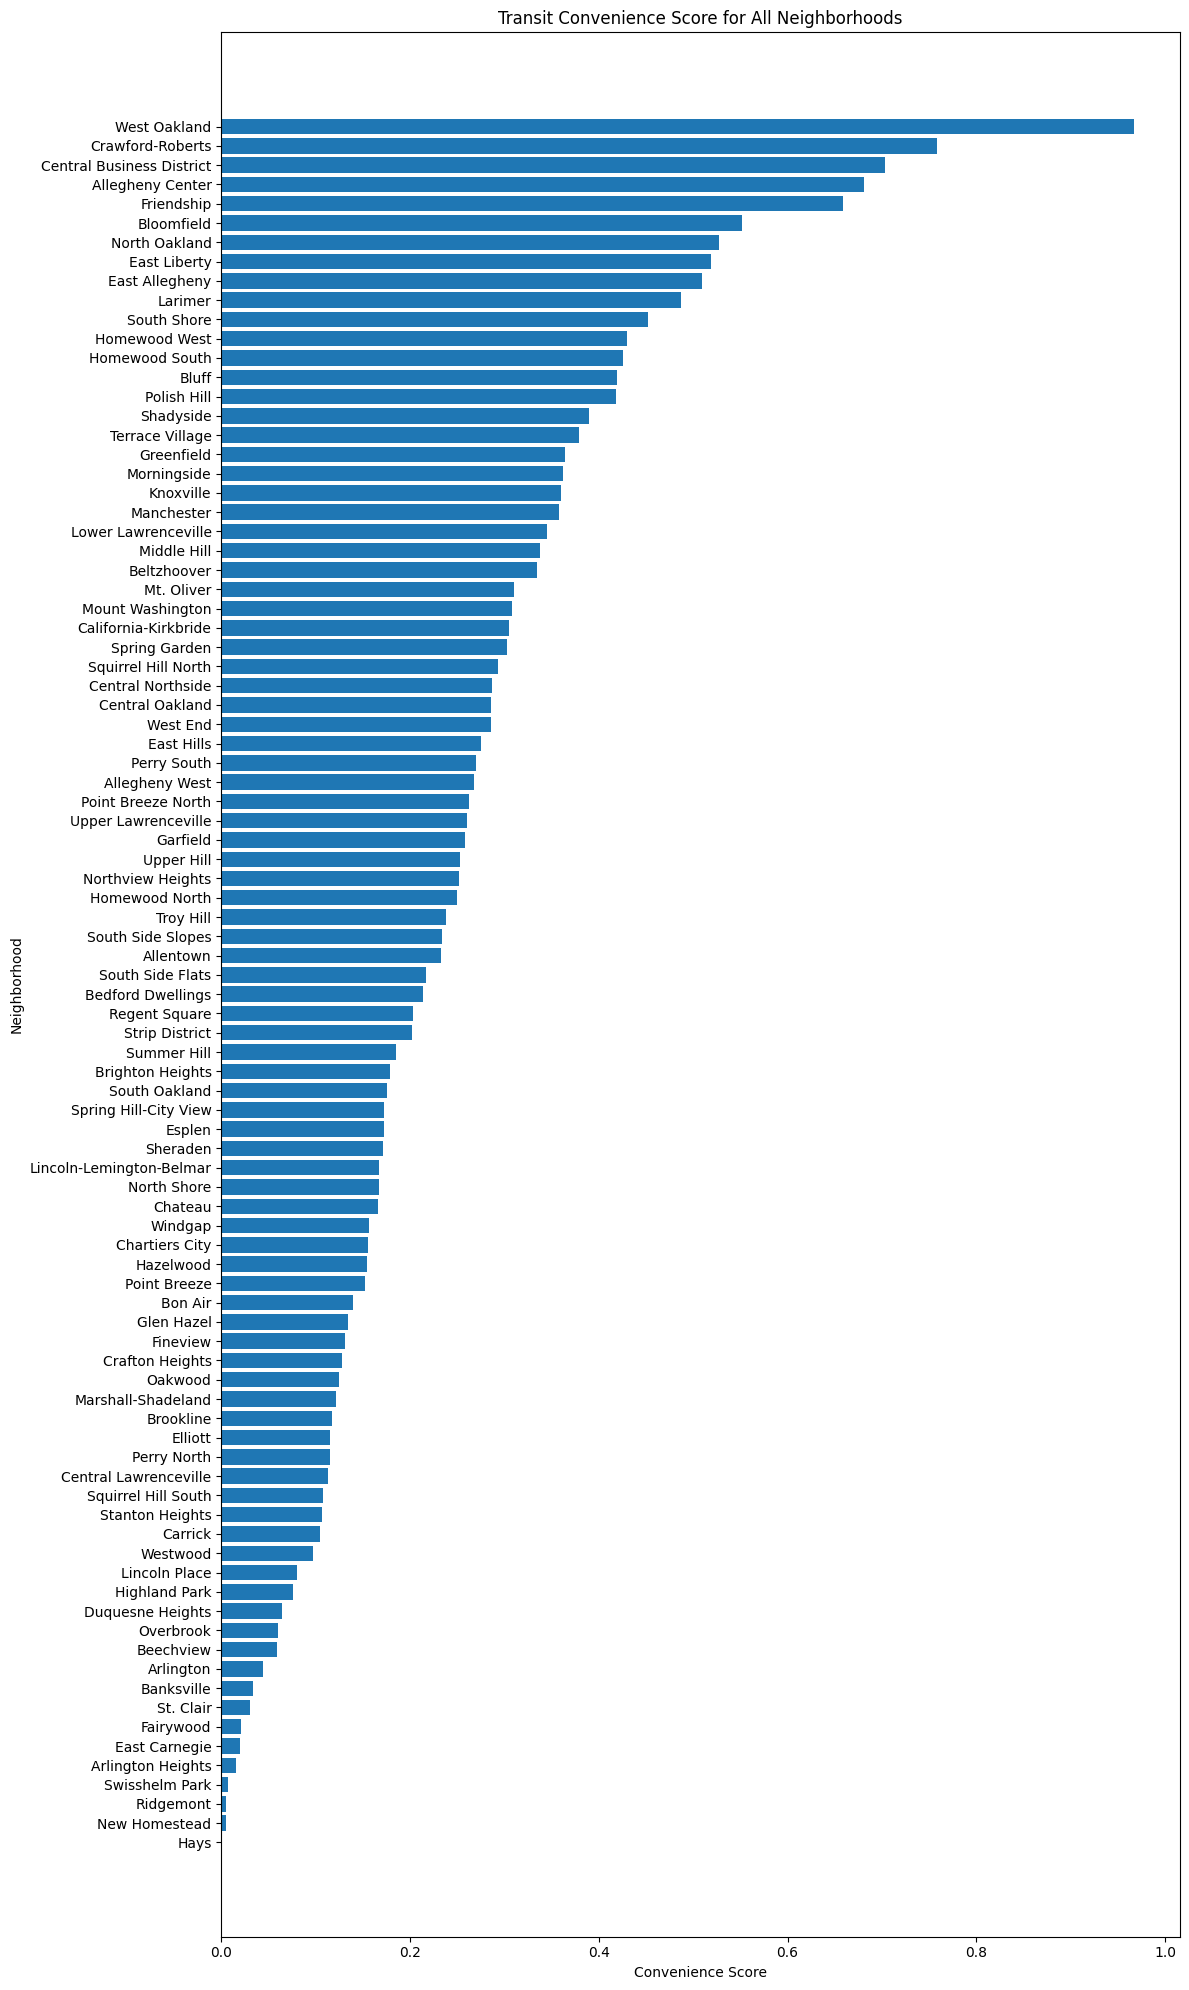

In [10]:
all_data = convenience_ranked.sort_values("convenience_score", ascending=True)

plt.figure(figsize=(12, 20)) 

plt.barh(all_data["neighborhood"], all_data["convenience_score"])

plt.xlabel("Convenience Score")
plt.ylabel("Neighborhood")
plt.title("Transit Convenience Score for All Neighborhoods")

plt.tight_layout()
plt.show()

## 6. Map the convenience score

This map helps show whether the most convenient neighborhoods are clustered around central Pittsburgh or spread across the city.


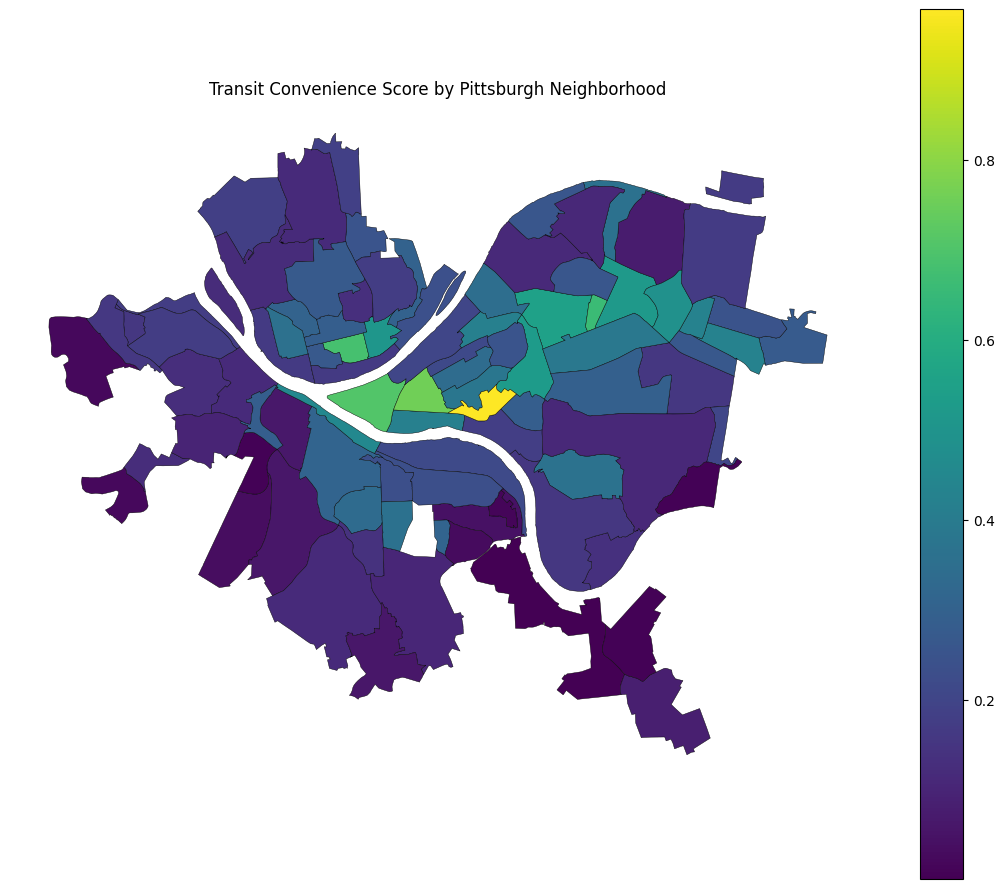

In [11]:
map_gdf = neighborhoods_aligned.merge(
    convenience_ranked[["neighborhood", "convenience_score", "rank", "stop_count", "weekly_trips", "stops_per_sq_mile", "trips_per_sq_mile"]],
    on="neighborhood",
    how="left"
)

fig, ax = plt.subplots(figsize=(11, 9))
map_gdf.plot(
    column="convenience_score",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)
ax.set_title("Transit Convenience Score by Pittsburgh Neighborhood")
ax.axis("off")
plt.tight_layout()
plt.show()

In [13]:
aligned_project_table = convenience_ranked.copy()

if TREES_FILE.exists():
    trees = pd.read_csv(TREES_FILE, usecols=["neighborhood"])
    trees["neighborhood"] = trees["neighborhood"].apply(clean_name)

    tree_summary = (
        trees
        .dropna(subset=["neighborhood"])
        .groupby("neighborhood")
        .size()
        .reset_index(name="tree_count")
    )

    aligned_project_table = aligned_project_table.merge(tree_summary, on="neighborhood", how="left")
    aligned_project_table["tree_count"] = aligned_project_table["tree_count"].fillna(0).astype(int)

    print("Tree data found and aligned.")
else:
    print("Tree file not found. Skipping tree alignment.")

display(aligned_project_table)

Tree data found and aligned.


,neighborhood,neighborhood_size,stop_count,weekly_trips,stops_per_sq_mile,trips_per_sq_mile,stop_density_norm,trip_density_norm,convenience_score,rank,tree_count
0,West Oakland,0.215,32,40303,148.837209,187455.813953,0.934948,1.000000,0.967474,1,78
1,Crawford-Roberts,0.258,41,25063,158.914729,97143.410853,1.000000,0.517335,0.758668,2,568
2,Central Business District,0.640,69,88486,107.812500,138259.375000,0.670127,0.737075,0.703601,3,1002
3,Allegheny Center,0.210,27,21976,128.571429,104647.619048,0.804129,0.557441,0.680785,4,867
4,Friendship,0.106,15,8547,141.509434,80632.075472,0.887646,0.429092,0.658369,5,362
5,Bloomfield,0.702,92,37354,131.054131,53210.826211,0.820155,0.282542,0.551349,6,1436
6,North Oakland,0.499,42,50305,84.168337,100811.623246,0.517500,0.536940,0.527220,7,775
7,East Liberty,0.581,63,39795,108.433735,68493.975904,0.674137,0.364221,0.519179,8,1366
8,East Allegheny,0.236,28,12392,118.644068,52508.474576,0.740046,0.278789,0.509417,9,391
9,Larimer,0.445,52,20609,116.853933,46312.359551,0.728491,0.245674,0.487082,10,306


In [14]:
# Export the clean aligned table for use in the final report or for merging with teammates' metrics.
output_file = "aligned_neighborhood_convenience_scores.csv"
aligned_project_table.to_csv(output_file, index=False)

print(f"Saved: {output_file}")

Saved: aligned_neighborhood_convenience_scores.csv


In [12]:
best = convenience_ranked.iloc[0]

print("Best neighborhood by this convenience metric:")
print(best[["rank", "neighborhood", "convenience_score", "stop_count", "weekly_trips", "stops_per_sq_mile", "trips_per_sq_mile"]])


Best neighborhood by this convenience metric:
rank                             1
neighborhood          West Oakland
convenience_score         0.967474
stop_count                      32
weekly_trips                 40303
stops_per_sq_mile       148.837209
trips_per_sq_mile    187455.813953
Name: 0, dtype: object
